<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Ensambles_Telco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Cargar el dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Arreglar la "trampa" de TotalCharges
# Forzamos a que sea número. Los espacios vacíos se vuelven NaN (nulos) y luego los borramos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# 3. Eliminar ID (no sirve para predecir)
df = df.drop(columns=['customerID'])

# 4. Convertir la variable objetivo 'Churn' a 1 y 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. Encoding de las variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

# 6. Separar en X e y, y dividir
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Datos listos. Filas para entrenar: {X_train.shape[0]}, Columnas: {X_train.shape[1]}")

Datos listos. Filas para entrenar: 5625, Columnas: 30


In [4]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciar el Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)

# 2. Entrenar
rf_model.fit(X_train, y_train)

# 3. Predecir y Evaluar
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST (Bagging)")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

RANDOM FOREST (Bagging)
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC Score: 0.8376


In [5]:
from xgboost import XGBClassifier

# 1. Calcular el peso para el desbalance
peso_desbalance = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. Instanciar XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=peso_desbalance,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

# 3. Entrenar
xgb_model.fit(X_train, y_train)

# 4. Predecir y Evaluar
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBOOST (Boosting)")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")


XGBOOST (Boosting)
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC-AUC Score: 0.8383


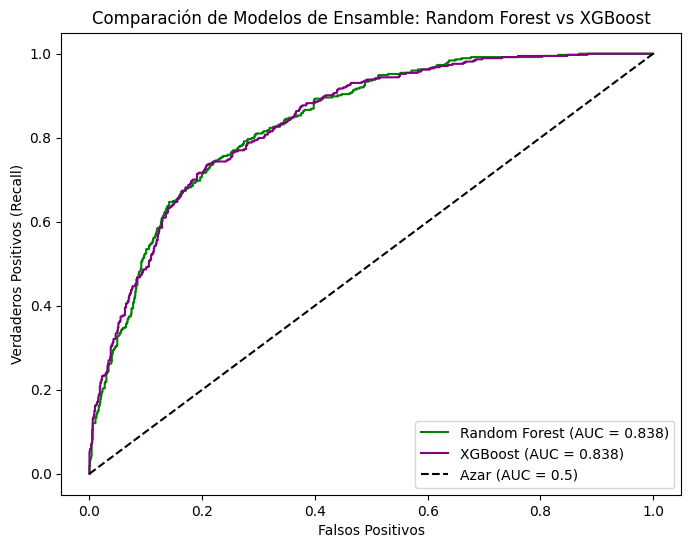

In [6]:
# Calcular las curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')

plt.title('Comparación de Modelos de Ensamble: Random Forest vs XGBoost')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.show()

### Conclusiones: Bagging vs Boosting en Telco Churn

**1. Análisis de Rendimiento Comparativo**
Tras evaluar las técnicas de ensamble, observamos un rendimiento sumamente parejo entre **Random Forest (Bagging)** y **XGBoost (Boosting)**. Ambos modelos lograron un área bajo la curva (ROC-AUC) de ~0.838, demostrando una excelente capacidad general para discriminar entre las clases.

**2. Decisión basada en el Negocio (Recall)**
Dado que el objetivo estratégico de la compañía de telecomunicaciones es la retención proactiva, nuestra métrica crítica es el **Recall de la clase 1 (Churn)**.
* **Random Forest** logró capturar el **80%** de las fugas reales.
* **XGBoost** capturó el **79%**.

**3. Recomendación Final**
Aunque XGBoost tiene un ROC-AUC marginalmente superior, **recomendamos implementar Random Forest**. No solo logró un Recall levemente mejor, sino que al ser un modelo de Bagging (entrenamiento en paralelo) tiende a ser menos propenso al sobreajuste frente a variaciones futuras en los datos y requiere menos mantenimiento de hiperparámetros que un modelo de Boosting.

El trade-off asumido es una precisión del 50%, lo que implica que la mitad de los esfuerzos de retención se dirigirán a "falsos positivos". Desde la perspectiva financiera, el costo de estas campañas preventivas es significativamente menor que el Costo de Adquisición de Clientes (CAC) necesario para reemplazar el 80% de fugas que el modelo ahora es capaz de detectar.